# K-Means Clustering - IRIS Dataset

## Steps:
    1. Load and normalize IRIS data
    2. K-Means from scratch with empty cluster handling
    3. Multiple runs to avoid local minima (initial centroid problem)
    4. Evaluation using SSE (Sum of Squared Error)
    5. Elbow method to choose K
    6. Cluster visualization
    7. Comparison with scikit-learn (Weka equivalent)

In [1]:
# importamos las librerías necesarias 
import numpy as np                              # para operaciones matemáticas y vectores
import matplotlib.pyplot as plt                 # para graficar
from sklearn.datasets import load_iris          # dataset IRIS ya incluido en scikit-learn
from sklearn.preprocessing import StandardScaler   # para normalizar los datos
from sklearn.cluster import KMeans as SklearnKMeans  # K-Means oficial, solo para comparar al final
 

## STEP 1: Load and normalize data

In [4]:
print("=" * 60)
print("STEP 1: Loading and normalizing IRIS data")
print("=" * 60)
 
iris = load_iris()              # cargamos el dataset IRIS completo
 
X_raw = iris.data               # matriz de 150 filas x 4 columnas con los valores reales
y_real = iris.target            # etiqueta real de cada flor (0=setosa, 1=versicolor, 2=virginica)
feature_names = iris.feature_names   # nombres de las 4 columnas (largo/ancho de sépalos y pétalos)
class_names = iris.target_names      # nombres de las 3 especies
 
print(f"Dataset: {X_raw.shape[0]} samples, {X_raw.shape[1]} features")
print(f"Features: {feature_names}")
print(f"Real classes: {class_names}")
print(f"\nExample raw data (first 3 rows):")
print(X_raw[:3])

# Normalizamos los datos con StandardScaler
# Esto transforma cada feature para que tenga media=0 y desviación estándar=1
# Es importante porque K-Means usa distancias Euclidianas:
# si una feature tiene valores 0-10 y otra 0-1000, la segunda domina injustamente
scaler = StandardScaler()           # creamos el normalizador
X = scaler.fit_transform(X_raw)     # calculamos media/std de X_raw y aplicamos la transformación
 
print(f"\nExample normalized data (first 3 rows):")
print(np.round(X[:3], 4))           # redondeamos a 4 decimales solo para mostrar en pantalla

STEP 1: Loading and normalizing IRIS data
Dataset: 150 samples, 4 features
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Real classes: ['setosa' 'versicolor' 'virginica']

Example raw data (first 3 rows):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]

Example normalized data (first 3 rows):
[[-0.9007  1.019  -1.3402 -1.3154]
 [-1.143  -0.132  -1.3402 -1.3154]
 [-1.3854  0.3284 -1.3971 -1.3154]]


## STEP 2: K-Means implementation from scratch


In [5]:
print("\n" + "=" * 60)
print("STEP 2: K-Means implementation from scratch")
print("=" * 60)
 
 
def calculate_sse(X, labels, centroids):
    """
    Calculates the SSE (Sum of Squared Error).
    SSE = suma de las distancias al cuadrado de cada punto a su centroide asignado.
    Fórmula del PPT slide 63: SSE = Σ dist²(mᵢ, x) para todo x en Cᵢ
    Cuanto más bajo el SSE, más compactos son los clusters → mejor resultado.
    """
    sse = 0.0                               # inicializamos el error acumulado en 0
    for i in range(len(X)):                 # iteramos sobre cada punto del dataset
        diff = X[i] - centroids[labels[i]] # vector diferencia entre el punto y su centroide
        sse += np.linalg.norm(diff) ** 2   # sumamos la distancia al cuadrado (norma euclidiana²)
    return sse
 
 
def kmeans(X, k, max_iters=100, seed=42):
    """
    K-Means algorithm from scratch.
    Implementa los 5 pasos del PPT (slides 44-58):
      Step 1: Determinar K (recibido como parámetro)
      Step 2: Elegir K centroides iniciales aleatoriamente
      Step 3: Calcular distancia Euclidiana de cada punto a cada centroide
      Step 4: Asignar cada punto al centroide más cercano
      Step 5: Recalcular nuevos centroides como promedio del cluster
      → Repetir Steps 3-5 hasta convergencia
 
    Parámetros:
      X        : matriz de datos normalizados (150 x 4)
      k        : número de clusters a crear
      max_iters: máximo de iteraciones antes de forzar parada
      seed     : semilla de aleatoriedad (para que los resultados sean reproducibles)
 
    Retorna:
      labels      : array con el número de cluster asignado a cada punto (0 a k-1)
      centroids   : posición final de los k centroides
      sse_final   : SSE calculado con los centroides finales
      sse_history : lista del SSE en cada iteración (para graficar la curva de aprendizaje)
    """
    np.random.seed(seed)    # fijamos la semilla para que los resultados sean reproducibles
 
    # Step 2: seleccionamos k índices al azar sin repetición y tomamos esos puntos como centroides iniciales
    initial_idx = np.random.choice(len(X), k, replace=False)   # k índices aleatorios entre 0 y 149
    centroids = X[initial_idx].copy()                           # copiamos las filas correspondientes
 
    sse_history = []    # lista vacía que irá guardando el SSE de cada iteración
 
    for iteration in range(max_iters):  # repetimos hasta max_iters veces (o hasta converger antes)


        # Step 3: calculamos la distancia Euclidiana de CADA punto a CADA centroide
        # X[:, np.newaxis] tiene shape (150, 1, 4) — agregamos dimensión para broadcasting
        # centroids tiene shape (k, 4)
        # La resta produce shape (150, k, 4) → norma sobre axis=2 → shape (150, k)
        # Resultado: distances[i][j] = distancia del punto i al centroide j
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
 
        # Step 4: asignamos cada punto al centroide más cercano
        # argmin sobre axis=1 devuelve el índice (0..k-1) del centroide más cercano para cada punto
        labels = np.argmin(distances, axis=1)
 
        # Registramos el SSE de esta iteración para poder graficar la curva de aprendizaje después
        sse_iter = calculate_sse(X, labels, centroids)
        sse_history.append(sse_iter)
 
        # Step 5: recalculamos los centroides como el promedio de todos los puntos del cluster
        new_centroids = []              # lista vacía para los nuevos centroides
        for i in range(k):             # iteramos sobre cada cluster
            cluster_points = X[labels == i]     # filtramos los puntos que pertenecen al cluster i
 
            if len(cluster_points) == 0:
                # Manejo de cluster vacío (PPT slide 76):
                # Si ningún punto fue asignado a este cluster, elegimos el punto más
                # alejado de cualquier centroide actual como nuevo centroide
                min_distances = np.min(distances, axis=1)       # distancia mínima de cada punto a cualquier centroide
                new_centroids.append(X[np.argmax(min_distances)])  # tomamos el punto con mayor distancia mínima
                print(f"  WARNING iter {iteration+1}: Cluster {i} empty — reassigned to farthest point")
            else:
                # Caso normal: el nuevo centroide es el promedio de todos los puntos del cluster
                new_centroids.append(cluster_points.mean(axis=0))  # .mean(axis=0) promedia por columna
 
        new_centroids = np.array(new_centroids)     # convertimos la lista en un array numpy
 
        # Verificamos convergencia: si los centroides no se movieron (diferencia < 1e-6), terminamos
        # np.allclose compara dos arrays elemento a elemento con tolerancia atol
        if np.allclose(centroids, new_centroids, atol=1e-6):
            print(f"  Converged at iteration {iteration + 1} | Final SSE: {sse_iter:.4f}")
            centroids = new_centroids   # actualizamos centroides antes de salir
            break                       # salimos del loop — ya convergió
 
        centroids = new_centroids       # actualizamos centroides para la siguiente iteración
 
    else:
        # Este bloque solo se ejecuta si el for terminó sin hacer break (nunca convergió)
        print(f"  Reached max iterations ({max_iters}) | Final SSE: {sse_history[-1]:.4f}")
 
    # Calculamos el SSE final con los centroides definitivos
    final_sse = calculate_sse(X, labels, centroids)
    return labels, centroids, final_sse, sse_history
 
 



STEP 2: K-Means implementation from scratch


## STEP 3: Multiple runs to avoid local minima

In [6]:
print("\n" + "=" * 60)
print("STEP 3: Multiple runs per K (initial centroid problem)")
print("         PPT slide 74: 'Multiple runs — help, but probability is not on your side'")
print("=" * 60)
 
# El problema: los centroides iniciales se eligen aleatoriamente → si caen en una
# mala posición, K-Means converge a un mínimo local (resultado subóptimo)
# La solución del PPT: correr el algoritmo varias veces con semillas distintas
# y quedarse con el resultado que tenga el SSE más bajo
 
NUM_RUNS = 10           # cantidad de veces que corremos K-Means por cada K
K_VALUES = [2, 3, 4, 5] # valores de K que vamos a probar
 
results = {}    # diccionario que guardará el mejor resultado para cada K
 
for k in K_VALUES:
    print(f"\n--- K = {k} ---")
    best_sse = float('inf')     # inicializamos el mejor SSE en infinito (cualquier resultado será mejor)
    best_labels = None          # aquí guardaremos las etiquetas del mejor resultado
    best_centroids = None       # aquí guardaremos los centroides del mejor resultado
    best_history = None         # aquí guardaremos el historial de SSE del mejor resultado
 
    for seed in range(NUM_RUNS):    # corremos K-Means NUM_RUNS veces con semillas 0, 1, 2, ..., 9
        labels, centroids, sse, history = kmeans(X, k=k, seed=seed)
 
        if sse < best_sse:          # si este resultado es mejor que el mejor anterior...
            best_sse = sse          # actualizamos el mejor SSE
            best_labels = labels    # guardamos las etiquetas
            best_centroids = centroids  # guardamos los centroides
            best_history = history  # guardamos el historial
 
    print(f"  Best SSE for K={k}: {best_sse:.4f}")
 
    # Guardamos el mejor resultado de este K en el diccionario
    results[k] = {
        'labels':      best_labels,     # etiquetas de cluster para cada punto
        'centroids':   best_centroids,  # posición final de los centroides
        'sse':         best_sse,        # SSE del mejor resultado
        'sse_history': best_history     # curva de SSE por iteración
    }
 


STEP 3: Multiple runs per K (initial centroid problem)
         PPT slide 74: 'Multiple runs — help, but probability is not on your side'

--- K = 2 ---
  Converged at iteration 5 | Final SSE: 222.3617
  Converged at iteration 3 | Final SSE: 222.3617
  Converged at iteration 4 | Final SSE: 222.3617
  Converged at iteration 3 | Final SSE: 222.3617
  Converged at iteration 2 | Final SSE: 222.3617
  Converged at iteration 6 | Final SSE: 222.3617
  Converged at iteration 2 | Final SSE: 222.3617
  Converged at iteration 5 | Final SSE: 222.3617
  Converged at iteration 4 | Final SSE: 222.3617
  Converged at iteration 7 | Final SSE: 222.3617
  Best SSE for K=2: 222.3617

--- K = 3 ---
  Converged at iteration 6 | Final SSE: 140.9015
  Converged at iteration 8 | Final SSE: 140.9015
  Converged at iteration 5 | Final SSE: 191.0247
  Converged at iteration 8 | Final SSE: 140.9015
  Converged at iteration 8 | Final SSE: 140.0328
  Converged at iteration 7 | Final SSE: 140.0328
  Converged at ite

## STEP 4: Elbow method to choose the best K


STEP 4: Elbow method — choosing the best K
  K=2  →  SSE = 222.3617
  K=3  →  SSE = 140.0328
  K=4  →  SSE = 114.3538
  K=5  →  SSE = 91.5554


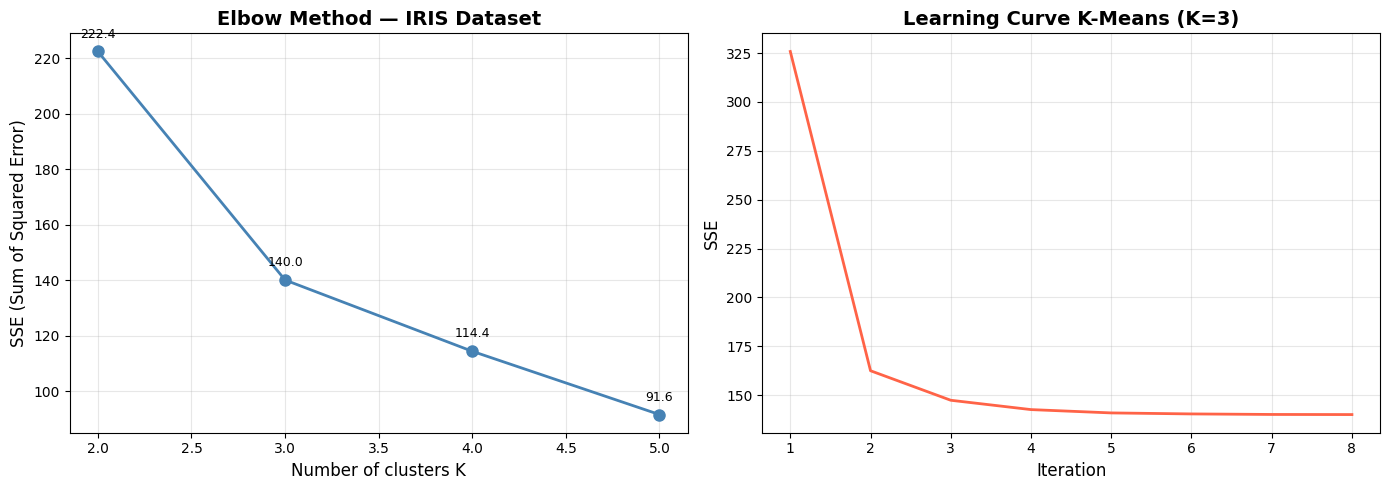

  Saved: kmeans_curves.png


In [7]:
print("\n" + "=" * 60)
print("STEP 4: Elbow method — choosing the best K")
print("=" * 60)
 
ks   = list(results.keys())             # lista [2, 3, 4, 5]
sses = [results[k]['sse'] for k in ks]  # lista con el mejor SSE de cada K
 
for k, sse in zip(ks, sses):
    print(f"  K={k}  →  SSE = {sse:.4f}")
 
# Creamos una figura con dos gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# ── Gráfica 1: Método del codo ──────────────────────────────
# Graficamos SSE vs K — buscamos el "codo" donde la mejora se estabiliza
axes[0].plot(ks, sses, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters K', fontsize=12)
axes[0].set_ylabel('SSE (Sum of Squared Error)', fontsize=12)
axes[0].set_title('Elbow Method — IRIS Dataset', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
for k, sse in zip(ks, sses):    # añadimos etiquetas numéricas encima de cada punto
    axes[0].annotate(f'{sse:.1f}', (k, sse),
                     textcoords="offset points", xytext=(0, 10),
                     ha='center', fontsize=9)
 
# ── Gráfica 2: Curva de aprendizaje para K=3 ────────────────
# Mostramos cómo el SSE baja con cada iteración — se vuelve más estable con el tiempo
history_k3 = results[3]['sse_history']  # recuperamos el historial del mejor run con K=3
axes[1].plot(range(1, len(history_k3) + 1), history_k3,
             color='tomato', linewidth=2)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('SSE', fontsize=12)
axes[1].set_title('Learning Curve K-Means (K=3)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()                          # ajustamos espaciado para que no se superpongan
plt.savefig('kmeans_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: kmeans_curves.png")
 

## STEP 5: Visualize clusters with K=3


STEP 5: Cluster visualization (K=3)


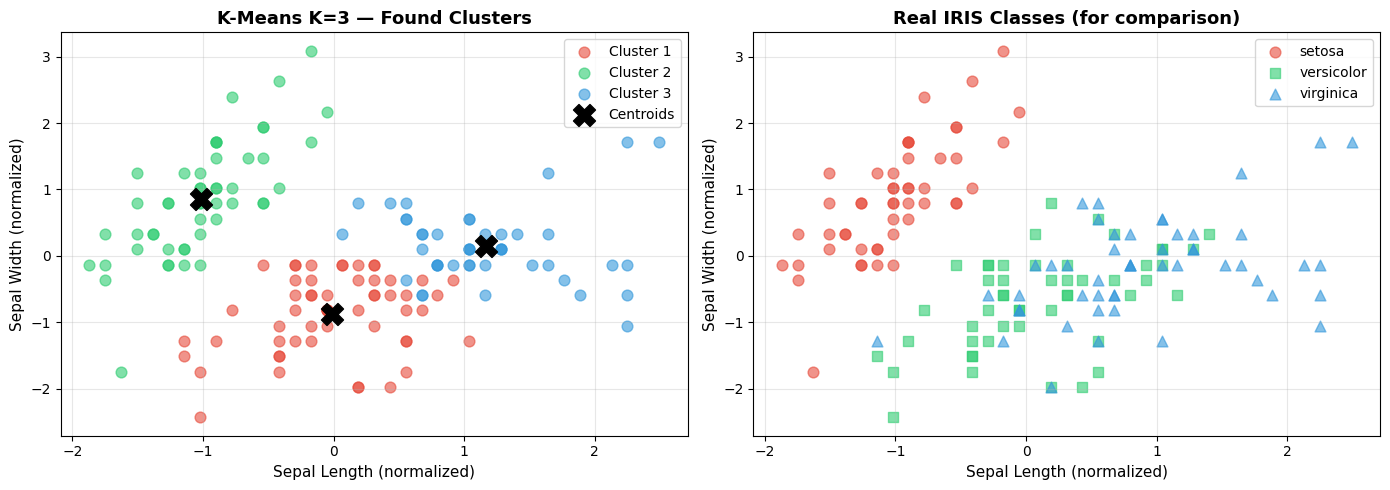

  Saved: kmeans_clusters.png

STEP 6: Comparison with scikit-learn (Weka equivalent)

  Our K-Means SSE    (K=3): 140.0328
  Scikit-learn SSE   (K=3): 139.8205
  Difference:               0.2123 (0.15%)
  RESULT: Correct implementation (difference < 5%)

  Our K-Means centroids (normalized space):
    Cluster 1: [-0.0114 -0.876   0.3771  0.3112]
    Cluster 2: [-1.0146  0.8533 -1.305  -1.2549]
    Cluster 3: [1.1674 0.1453 1.003  1.03  ]

  Scikit-learn / Weka centroids:
    Cluster 1: [-0.0502 -0.8834  0.3477  0.2815]
    Cluster 2: [-1.0146  0.8533 -1.305  -1.2549]
    Cluster 3: [1.136  0.0884 0.9962 1.0175]


In [8]:
print("\n" + "=" * 60)
print("STEP 5: Cluster visualization (K=3)")
print("=" * 60)
 
labels_k3    = results[3]['labels']     # etiquetas asignadas por K-Means para K=3
centroids_k3 = results[3]['centroids']  # posición de los 3 centroides finales
colors       = ['#E74C3C', '#2ECC71', '#3498DB']   # rojo, verde, azul — uno por cluster
real_markers = ['o', 's', '^']          # círculo, cuadrado, triángulo — uno por especie real
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# ── Plot 1: clusters encontrados por nuestro K-Means ────────
for i in range(3):                          # iteramos sobre cada cluster (0, 1, 2)
    points = X[labels_k3 == i]              # filtramos los puntos asignados al cluster i
    axes[0].scatter(
        points[:, 0], points[:, 1],         # usamos las 2 primeras features (sepal length/width) para el plano 2D
        c=colors[i], label=f'Cluster {i+1}',
        alpha=0.6, s=60                     # alpha=transparencia, s=tamaño de los puntos
    )
# Graficamos los centroides con una X negra grande para que destaquen
axes[0].scatter(
    centroids_k3[:, 0], centroids_k3[:, 1],
    c='black', marker='X', s=250, zorder=5, label='Centroids'  # zorder=5 para que queden encima de los puntos
)
axes[0].set_xlabel('Sepal Length (normalized)', fontsize=11)
axes[0].set_ylabel('Sepal Width (normalized)', fontsize=11)
axes[0].set_title('K-Means K=3 — Found Clusters', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# ── Plot 2: clases reales del dataset para comparar visualmente ──
for i, class_name in enumerate(class_names):    # iteramos sobre las 3 especies reales
    points = X[y_real == i]                     # filtramos los puntos de la especie i
    axes[1].scatter(
        points[:, 0], points[:, 1],
        c=colors[i], marker=real_markers[i],    # usamos el marcador distinto por especie
        label=class_name, alpha=0.6, s=60
    )
axes[1].set_xlabel('Sepal Length (normalized)', fontsize=11)
axes[1].set_ylabel('Sepal Width (normalized)', fontsize=11)
axes[1].set_title('Real IRIS Classes (for comparison)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: kmeans_clusters.png")
 
 
# ============================================================
# STEP 6: Comparison with scikit-learn (Weka equivalent)
# ============================================================
print("\n" + "=" * 60)
print("STEP 6: Comparison with scikit-learn (Weka equivalent)")
print("=" * 60)
 
# Creamos y entrenamos el K-Means oficial de scikit-learn con los mismos parámetros
# n_init=10 significa que scikit-learn también corre 10 veces y se queda con el mejor resultado
sklearn_model = SklearnKMeans(n_clusters=3, n_init=10, random_state=42)
sklearn_model.fit(X)    # entrenamos con los datos normalizados
 
sse_sklearn = sklearn_model.inertia_    # .inertia_ es el SSE final que calcula scikit-learn
sse_ours    = results[3]['sse']         # SSE de nuestra implementación
 
print(f"\n  Our K-Means SSE    (K=3): {sse_ours:.4f}")
print(f"  Scikit-learn SSE   (K=3): {sse_sklearn:.4f}")
 
difference = abs(sse_ours - sse_sklearn)            # diferencia absoluta entre ambos SSE
percentage = (difference / sse_sklearn) * 100       # diferencia como porcentaje del SSE oficial
 
print(f"  Difference:               {difference:.4f} ({percentage:.2f}%)")
 
if percentage < 5:  # si la diferencia es menor al 5%, consideramos que la implementación es correcta
    print("  RESULT: Correct implementation (difference < 5%)")
else:
    print("  WARNING: Difference > 5% — check implementation")
 
# Mostramos los centroides de ambas implementaciones para comparar directamente
print(f"\n  Our K-Means centroids (normalized space):")
for i, c in enumerate(centroids_k3):
    print(f"    Cluster {i+1}: {np.round(c, 4)}")   # redondeamos a 4 decimales para legibilidad
 
print(f"\n  Scikit-learn / Weka centroids:")
for i, c in enumerate(sklearn_model.cluster_centers_):
    print(f"    Cluster {i+1}: {np.round(c, 4)}")
 

## Summary

In [9]:
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Dataset:        IRIS ({X.shape[0]} samples, {X.shape[1]} features)")
print(f"  Normalization:  StandardScaler (mean=0, std=1)")
print(f"  Runs per K:     {NUM_RUNS} (to avoid local minima)")
print(f"  K tested:       {K_VALUES}")
print(f"  Best K (elbow): K=3  →  SSE = {results[3]['sse']:.4f}")
print(f"  Output files:   kmeans_curves.png, kmeans_clusters.png")
print("=" * 60)
 


FINAL SUMMARY
  Dataset:        IRIS (150 samples, 4 features)
  Normalization:  StandardScaler (mean=0, std=1)
  Runs per K:     10 (to avoid local minima)
  K tested:       [2, 3, 4, 5]
  Best K (elbow): K=3  →  SSE = 140.0328
  Output files:   kmeans_curves.png, kmeans_clusters.png
